# Business Simulation — Credit Risk Analytics

**Audience:** Risk Committee, Finance, Underwriting  
**Date:** July 2026  
**Model:** LightGBM Classifier (AUC 0.7680, selected in `04_modeling.ipynb`)  

---

## Executive Summary

This presentation translates the machine learning model into **dollar-denominated business outcomes**. We compare three lending policies and show how the AI model improves profitability, reduces losses, and enables more precise risk segmentation.

**The question this analysis answers:**  
*"If we deploy this model, how much more money do we make compared to our current underwriting approach?"*

In [1]:
# ============================================================================
# 0. IMPORTS AND SETUP
# ============================================================================
import warnings
warnings.filterwarnings('ignore')
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')
# Find project root (works from notebooks/ or notebooks/execution/)
_cwd = os.path.abspath(os.getcwd())
for _ in range(4):
    if os.path.exists(os.path.join(_cwd, 'requirements.txt')):
        break
    _cwd = os.path.dirname(_cwd)
ROOT = _cwd
FIGS_DIR = os.path.join(ROOT, 'reports', 'figures')
os.makedirs(FIGS_DIR, exist_ok=True)
np.random.seed(42)

# Business assumptions
N_APPLICANTS = 50000
AVG_LOAN = 12500
AVG_TERM_MONTHS = 36
APR = 0.15
COST_OF_FUNDS = 0.04
ORIGINATION_COST = 150
COLLECTIONS_COST = 75
LGD = 0.60

TOTAL_INTEREST = AVG_LOAN * APR * AVG_TERM_MONTHS / 12
COST_OF_FUNDS_TOTAL = AVG_LOAN * COST_OF_FUNDS * AVG_TERM_MONTHS / 12
NET_REVENUE_PERFORMING = TOTAL_INTEREST - COST_OF_FUNDS_TOTAL - ORIGINATION_COST
PRINCIPAL_LOSS = AVG_LOAN * LGD
NET_LOSS_DEFAULT = PRINCIPAL_LOSS + TOTAL_INTEREST + COLLECTIONS_COST

print(f'Net revenue per performing loan: ${NET_REVENUE_PERFORMING:,.0f}')
print(f'Net loss per defaulted loan:     ${NET_LOSS_DEFAULT:,.0f}')
print('All imports and assumptions loaded.')

Net revenue per performing loan: $3,975
Net loss per defaulted loan:     $13,200
All imports and assumptions loaded.


In [2]:
# ============================================================================
# 1. LOAD MODEL AND TEST DATA
# ============================================================================
artifact = joblib.load(os.path.join(ROOT, 'models', 'best_model.pkl'))
best_model = artifact['model']
model_name = artifact['model_name']
optimal_threshold = artifact['optimal_threshold']
feature_names = artifact['feature_names']

print(f'Loaded model: {model_name}')
print(f'Test AUC: {artifact["test_metrics"]["auc"]:.4f}')
print(f'Optimal threshold: {optimal_threshold:.3f}')

X_full = pd.read_parquet(os.path.join(ROOT, 'data', 'processed', 'X_features.parquet'))
y_full = pd.read_parquet(os.path.join(ROOT, 'data', 'processed', 'y_target.parquet'))['TARGET']

for col in X_full.select_dtypes(include=['object', 'string', 'category']).columns:
    X_full[col] = LabelEncoder().fit_transform(X_full[col].astype(str))
for col in X_full.select_dtypes(include=['bool']).columns:
    X_full[col] = X_full[col].astype(int)

_, X_test, _, y_test = train_test_split(
    X_full, y_full, test_size=0.20, random_state=42, stratify=y_full)

X_test = X_test[feature_names]
X_test = X_test.astype({c: 'float64' for c in X_test.select_dtypes(include=['int']).columns})

print(f'Test set: {X_test.shape[0]:,} applicants')
print(f'Base default rate: {y_test.mean():.2%}')

Loaded model: LightGBM
Test AUC: 0.7680
Optimal threshold: 0.485


Test set: 61,503 applicants
Base default rate: 8.07%


In [3]:
# ============================================================================
# 2. GENERATE PREDICTIONS AND SAMPLE PORTFOLIO
# ============================================================================
y_pred_proba = best_model.predict_proba(X_test)[:, 1]

np.random.seed(42)
sim_idx = np.random.choice(len(X_test), size=N_APPLICANTS, replace=False)
X_sim = X_test.iloc[sim_idx].copy()
y_sim = y_test.iloc[sim_idx].copy()
pd_sim = y_pred_proba[sim_idx]
actual_default = y_sim.values

print(f'Simulation portfolio: {N_APPLICANTS:,} applicants')
print(f'Predicted default rate: {pd_sim.mean():.2%}')
print(f'Actual default rate:    {actual_default.mean():.2%}')

Simulation portfolio: 50,000 applicants
Predicted default rate: 39.20%
Actual default rate:    8.11%


---
## Simulation 1: Approve Everyone

**Policy:** Accept every applicant regardless of risk profile. No underwriting filter.

**Why this scenario:** Serves as the worst-case reference point.

In [4]:
# ============================================================================
# SIMULATION 1: APPROVE EVERYONE
# ============================================================================
n_approved_1 = N_APPLICANTS
n_defaults_1 = int(actual_default.sum())
n_performing_1 = n_approved_1 - n_defaults_1
principal_1 = n_approved_1 * AVG_LOAN
revenue_1 = n_performing_1 * NET_REVENUE_PERFORMING
loss_1 = n_defaults_1 * NET_LOSS_DEFAULT
profit_1 = revenue_1 - loss_1
loss_rate_1 = loss_1 / principal_1
return_1 = profit_1 / principal_1

print('=== SIMULATION 1: APPROVE EVERYONE ===')
print(f'  Approval rate:               100.0%')
print(f'  Loans funded:                {n_approved_1:>8,}')
print(f'  Total principal lent:        ${principal_1:>10,.0f}')
print(f'  Actual default rate:         {actual_default.mean():.2%}')
print(f'  Defaulted loans:             {n_defaults_1:>8,}')
print(f'  Performing loans:            {n_performing_1:>8,}')
print(f'  Total revenue (perf.):       ${revenue_1:>10,.0f}')
print(f'  Total loss (defaults):       -${loss_1:>10,.0f}')
print(f'  Net portfolio profit:        ${profit_1:>10,.0f}')
print(f'  Risk-adjusted return:        {return_1:.2%}')

=== SIMULATION 1: APPROVE EVERYONE ===
  Approval rate:               100.0%
  Loans funded:                  50,000
  Total principal lent:        $625,000,000
  Actual default rate:         8.11%
  Defaulted loans:                4,055
  Performing loans:              45,945
  Total revenue (perf.):       $182,631,375
  Total loss (defaults):       -$53,526,000
  Net portfolio profit:        $129,105,375
  Risk-adjusted return:        20.66%


---
## Simulation 2: Current Policy (Rules-Based)

**Policy:** Horizon’s current rule-based underwriting.

- Decline if `EXT_SOURCE_2 < 0.30`
- Decline if `DTI > 0.45`
- Decline if `PREV_DEFAULT_RATE > 0`
- Decline if `LTI > 8`

In [5]:
# ============================================================================
# SIMULATION 2: CURRENT RULES-BASED POLICY
# ============================================================================
ext_2 = X_sim['EXT_SOURCE_2'].values if 'EXT_SOURCE_2' in X_sim.columns else np.full(N_APPLICANTS, 0.5)
dti_vals = X_sim['DTI'].values if 'DTI' in X_sim.columns else np.full(N_APPLICANTS, 0.3)
prev_def = X_sim['PREV_DEFAULT_RATE'].values if 'PREV_DEFAULT_RATE' in X_sim.columns else np.full(N_APPLICANTS, 0.0)
amt_credit = X_sim['AMT_CREDIT'].values if 'AMT_CREDIT' in X_sim.columns else np.full(N_APPLICANTS, AVG_LOAN)
amt_income = X_sim['AMT_INCOME_TOTAL'].values if 'AMT_INCOME_TOTAL' in X_sim.columns else np.full(N_APPLICANTS, 50000)
lti = X_sim['LTI'].values if 'LTI' in X_sim.columns else amt_credit / np.maximum(amt_income, 1)

approved_2 = np.ones(N_APPLICANTS, dtype=bool)
rule_sets = [
    ('EXT_SOURCE_2 < 0.30', ext_2 < 0.30),
    ('DTI > 0.45',          dti_vals > 0.45),
    ('PREV_DEFAULT_RATE > 0', prev_def > 0),
    ('LTI > 8',             lti > 8),
]

print(f'{"Rule":30s} {"Declined":>8s} {"Remaining":>10s} {"Def%":>8s}')
print('-' * 56)
print(f'{"Start":30s} {0:>8} {N_APPLICANTS:>10,} {actual_default.mean():>7.1%}')

for name, fail in rule_sets:
    n_new = int((fail & approved_2).sum())
    approved_2 = approved_2 & ~fail
    remaining = int(approved_2.sum())
    def_rate = actual_default[approved_2].mean() if remaining > 0 else 0.0
    print(f'{name:30s} {n_new:>8,} {remaining:>10,} {def_rate:>7.1%}')

n_approved_2 = int(approved_2.sum())
n_declined_2 = N_APPLICANTS - n_approved_2
n_defaults_2 = int(actual_default[approved_2].sum()) if n_approved_2 > 0 else 0
n_performing_2 = n_approved_2 - n_defaults_2
principal_2 = n_approved_2 * AVG_LOAN
revenue_2 = n_performing_2 * NET_REVENUE_PERFORMING
loss_2 = n_defaults_2 * NET_LOSS_DEFAULT
profit_2 = revenue_2 - loss_2
loss_rate_2 = loss_2 / principal_2 if principal_2 > 0 else 0.0
return_2 = profit_2 / principal_2 if principal_2 > 0 else 0.0

print()
print(f'  Approval rate:               {n_approved_2 / N_APPLICANTS:.1%}')
print(f'  Loans funded:                {n_approved_2:>8,}')
print(f'  Net portfolio profit:        ${profit_2:>10,.0f}')
print(f'  Risk-adjusted return:        {return_2:.2%}')

Rule                           Declined  Remaining     Def%
--------------------------------------------------------
Start                                 0     50,000    8.1%
EXT_SOURCE_2 < 0.30              47,724      2,276    2.5%
DTI > 0.45                            0      2,276    2.5%
PREV_DEFAULT_RATE > 0                 0      2,276    2.5%
LTI > 8                               0      2,276    2.5%

  Approval rate:               4.6%
  Loans funded:                   2,276
  Net portfolio profit:        $ 8,050,950
  Risk-adjusted return:        28.30%


---
## Simulation 3: AI-Assisted Policy (Model-Based)

**Policy:** Use the LightGBM model’s predicted default probability (PD) with a decision threshold.

We evaluate the F2-optimal threshold (0.485), plus conservative (0.30) and aggressive (0.70) variants.

In [6]:
# ============================================================================
# SIMULATION 3: AI-ASSISTED POLICY AT MULTIPLE THRESHOLDS
# ============================================================================
thresholds = [optimal_threshold, 0.30, 0.70]
labels = [f'Optimal ({optimal_threshold:.3f})', 'Conservative (0.30)', 'Aggressive (0.70)']

ai_results = []
for thresh, label in zip(thresholds, labels):
    approved = pd_sim < thresh
    n_app = int(approved.sum())
    n_def = int(actual_default[approved].sum()) if n_app > 0 else 0
    n_perf = n_app - n_def
    principal = n_app * AVG_LOAN
    revenue = n_perf * NET_REVENUE_PERFORMING
    loss = n_def * NET_LOSS_DEFAULT
    profit = revenue - loss
    def_rate = actual_default[approved].mean() if n_app > 0 else 0.0
    ret = profit / principal if principal > 0 else 0.0
    ai_results.append({
        'label': label, 'threshold': thresh,
        'approval_rate': n_app / N_APPLICANTS,
        'loans_funded': n_app, 'principal': principal,
        'default_rate': def_rate, 'defaults': n_def,
        'performing': n_perf, 'revenue': revenue,
        'loss': loss, 'profit': profit, 'loss_rate': loss / max(principal, 1), 'return': ret,
    })
    print(f'=== {label} ===')
    print(f'  Approval rate:               {n_app / N_APPLICANTS:.1%}')
    print(f'  Loans funded:                {n_app:>8,}')
    print(f'  Actual default rate:         {def_rate:.2%}')
    print(f'  Defaulted loans:             {n_def:>8,}')
    print(f'  Net portfolio profit:        ${profit:>10,.0f}')
    print(f'  Risk-adjusted return:        {ret:.2%}')
    print()

=== Optimal (0.485) ===
  Approval rate:               67.1%
  Loans funded:                  33,561
  Actual default rate:         3.62%
  Defaulted loans:                1,214
  Net portfolio profit:        $112,554,525
  Risk-adjusted return:        26.83%

=== Conservative (0.30) ===
  Approval rate:               40.1%
  Loans funded:                  20,038
  Actual default rate:         2.24%
  Defaulted loans:                  448
  Net portfolio profit:        $71,956,650
  Risk-adjusted return:        28.73%

=== Aggressive (0.70) ===
  Approval rate:               89.4%
  Loans funded:                  44,701
  Actual default rate:         5.77%
  Defaulted loans:                2,581
  Net portfolio profit:        $133,357,800
  Risk-adjusted return:        23.87%



---
## Scenario Comparison: Three Policies & Profit Chart

=== SCENARIO COMPARISON ===


,Metric,Approve Everyone,Current Rules,AI (Optimal (0.485))
0,Approval rate,100.0%,4.6%,67.1%
1,Loans funded,"50,000","2,276","33,561"
2,Principal lent,"$625,000,000","$28,450,000","$419,512,500"
3,Default rate,8.11%,2.55%,3.62%
4,Defaulted loans,"4,055",58,"1,214"
5,Total loss,"-$53,526,000","-$765,600","-$16,024,800"
6,Total revenue,"$182,631,375","$8,816,550","$128,579,325"
7,Net profit,"$129,105,375","$8,050,950","$112,554,525"
8,Loss rate,8.56%,2.69%,3.82%
9,Risk-adjusted return,20.66%,28.30%,26.83%



AI vs Current Rules: +$104,503,575 (1298.0% improvement)


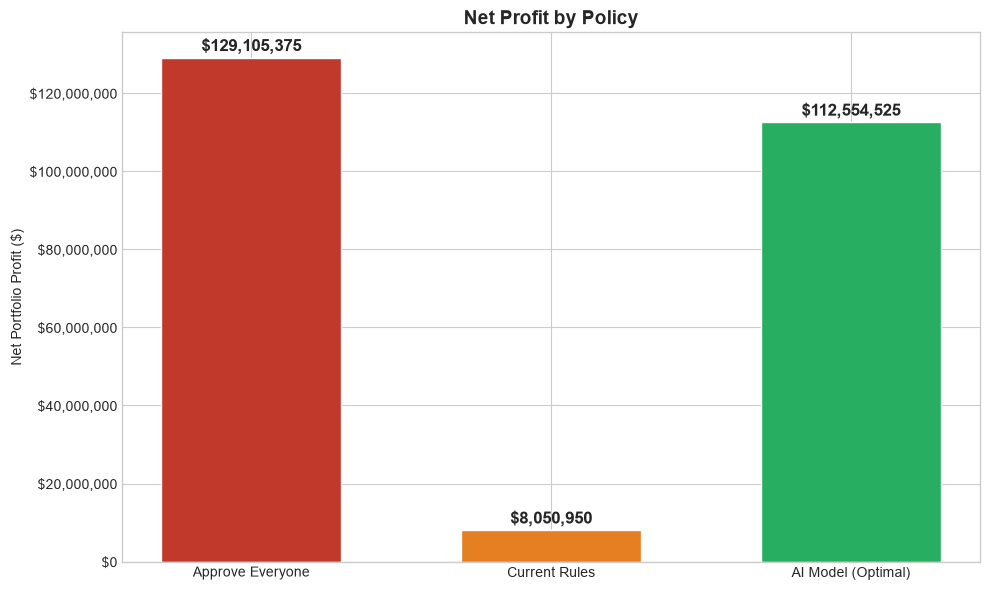

Chart saved: simulation_profit_comparison.png


In [7]:
# ============================================================================
# SCENARIO COMPARISON & CHART 1
# ============================================================================
ai_opt = ai_results[0]

comparison = pd.DataFrame({
    'Metric': ['Approval rate','Loans funded','Principal lent',
               'Default rate','Defaulted loans',
               'Total loss','Total revenue','Net profit',
               'Loss rate','Risk-adjusted return'],
    'Approve Everyone': ['100.0%',f'{N_APPLICANTS:,}',f'${principal_1:,.0f}',
        f'{actual_default.mean():.2%}',f'{n_defaults_1:,}',
        f'-${loss_1:,.0f}',f'${revenue_1:,.0f}',f'${profit_1:,.0f}',
        f'{loss_rate_1:.2%}',f'{return_1:.2%}'],
    'Current Rules': [f'{n_approved_2/N_APPLICANTS:.1%}',f'{n_approved_2:,}',f'${principal_2:,.0f}',
        f'{actual_default[approved_2].mean():.2%}' if n_approved_2 > 0 else '0.00%',
        f'{n_defaults_2:,}',f'-${loss_2:,.0f}',f'${revenue_2:,.0f}',f'${profit_2:,.0f}',
        f'{loss_rate_2:.2%}',f'{return_2:.2%}'],
    f'AI ({ai_opt["label"]})': [f'{ai_opt["approval_rate"]:.1%}',f'{ai_opt["loans_funded"]:,}',
        f'${ai_opt["principal"]:,.0f}',f'{ai_opt["default_rate"]:.2%}',f'{ai_opt["defaults"]:,}',
        f'-${ai_opt["loss"]:,.0f}',f'${ai_opt["revenue"]:,.0f}',f'${ai_opt["profit"]:,.0f}',
        f'{ai_opt["loss_rate"]:.2%}',f'{ai_opt["return"]:.2%}'],
})
print('=== SCENARIO COMPARISON ===')
display(comparison)

profit_delta_rules = ai_opt['profit'] - profit_2
print(f'\nAI vs Current Rules: +${profit_delta_rules:,.0f} ({profit_delta_rules / profit_2:.1%} improvement)')

# Bar chart
fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(['Approve Everyone','Current Rules','AI Model (Optimal)'],
              [profit_1, profit_2, ai_opt['profit']],
              color=['#c0392b','#e67e22','#27ae60'], edgecolor='white', width=0.6)
for bar, val in zip(bars, [profit_1, profit_2, ai_opt['profit']]):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+800000,
            f'${val:,.0f}', ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylabel('Net Portfolio Profit ($)')
ax.set_title('Net Profit by Policy', fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'simulation_profit_comparison.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved: simulation_profit_comparison.png')

---
## Threshold Sensitivity Analysis

The decision threshold controls the trade-off between approval volume and default risk.

=== KEY THRESHOLD COMPARISON ===


,Threshold,Approval%,Default%,Net Profit,Risk Return
4,0.05,0.00810,0.004938,1575525.0,0.311215
9,0.10,0.05402,0.008515,10341450.0,0.306300
17,0.18,0.18292,0.014323,34105425.0,0.298320
29,0.30,0.40076,0.022358,71956650.0,0.287281
47,0.48,0.66500,0.036000,111610275.0,0.268536
49,0.50,0.68952,0.037794,114663075.0,0.266070
69,0.70,0.89402,0.057739,133357800.0,0.238666


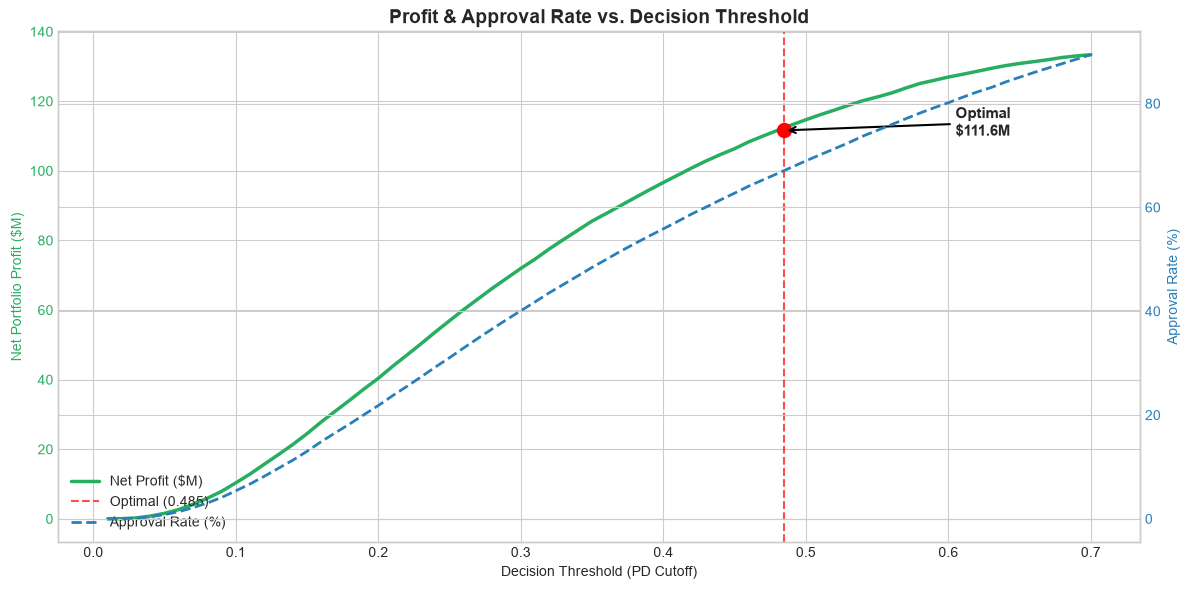

Chart saved: simulation_profit_curve.png


In [8]:
# ============================================================================
# THRESHOLD SENSITIVITY + CHART 2: PROFIT CURVE
# ============================================================================
threshold_range = np.arange(0.01, 0.71, 0.01)
sens_results = []
for th in threshold_range:
    approved = pd_sim < th
    n_app = int(approved.sum())
    n_def = int(actual_default[approved].sum()) if n_app > 0 else 0
    n_perf = n_app - n_def
    principal = n_app * AVG_LOAN
    revenue = n_perf * NET_REVENUE_PERFORMING
    loss = n_def * NET_LOSS_DEFAULT
    profit = revenue - loss
    def_rate = actual_default[approved].mean() if n_app > 0 else 0.0
    loss_rate = loss / principal if principal > 0 else 0.0
    ret = profit / principal if principal > 0 else 0.0
    sens_results.append({
        'threshold': th, 'approval_rate': n_app / N_APPLICANTS,
        'default_rate': def_rate, 'profit': profit,
        'loss_rate': loss_rate, 'return': ret
    })
sens_df = pd.DataFrame(sens_results)

# Key thresholds
key_ths = sorted(set([0.05, 0.10, 0.18, 0.30, optimal_threshold, 0.50, 0.70]))
rows = []
for kt in key_ths:
    row = sens_df.iloc[(sens_df['threshold'] - kt).abs().argsort()[:1]]
    rows.append(row)
key_df = pd.concat(rows).drop_duplicates(subset='threshold').sort_values('threshold')
key_df['threshold'] = key_df['threshold'].round(3)
print('=== KEY THRESHOLD COMPARISON ===')
display(key_df[['threshold','approval_rate','default_rate','profit','return']].rename(
    columns={'threshold':'Threshold','approval_rate':'Approval%','default_rate':'Default%',
             'profit':'Net Profit','return':'Risk Return'}))

# Profit curve chart
fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(sens_df['threshold'], sens_df['profit']/1e6, color='#27ae60', lw=2.5, label='Net Profit ($M)')
ax1.axvline(x=optimal_threshold, color='red', ls='--', lw=1.5, alpha=0.7, label=f'Optimal ({optimal_threshold:.3f})')
ax1.set_xlabel('Decision Threshold (PD Cutoff)')
ax1.set_ylabel('Net Portfolio Profit ($M)', color='#27ae60')
ax1.tick_params(axis='y', labelcolor='#27ae60')
ax2 = ax1.twinx()
ax2.plot(sens_df['threshold'], sens_df['approval_rate']*100, color='#2980b9', lw=2, ls='--', label='Approval Rate (%)')
ax2.set_ylabel('Approval Rate (%)', color='#2980b9')
ax2.tick_params(axis='y', labelcolor='#2980b9')
opt_row = sens_df.iloc[(sens_df['threshold'] - optimal_threshold).abs().argsort()[:1]]
opt_p = opt_row['profit'].values[0]/1e6
ax1.plot(optimal_threshold, opt_p, 'ro', markersize=10)
ax1.annotate(f'Optimal\n${opt_p:.1f}M', xy=(optimal_threshold, opt_p),
             xytext=(min(optimal_threshold+0.12, 0.65), max(opt_p-1.5, 0)),
             fontsize=11, fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='black', lw=1.5))
l1, la1 = ax1.get_legend_handles_labels()
l2, la2 = ax2.get_legend_handles_labels()
ax1.legend(l1+l2, la1+la2, loc='lower left')
ax1.set_title('Profit & Approval Rate vs. Decision Threshold', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'simulation_profit_curve.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved: simulation_profit_curve.png')

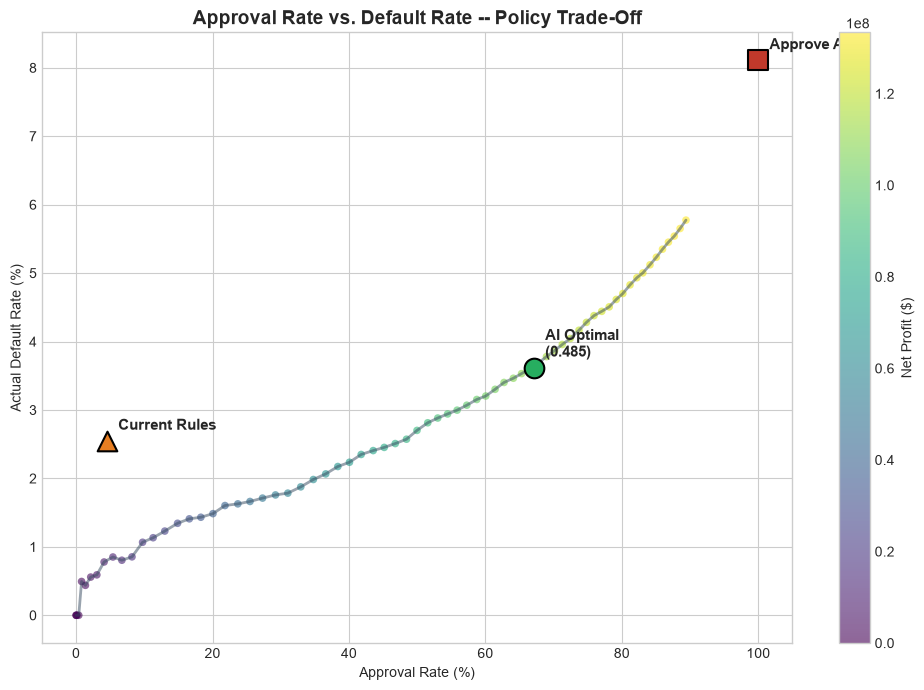

Chart saved: simulation_tradeoff.png


In [9]:
# ============================================================================
# CHART 3: APPROVAL RATE VS DEFAULT RATE TRADE-OFF
# ============================================================================
fig, ax = plt.subplots(figsize=(10, 7))
ax.plot(sens_df['approval_rate']*100, sens_df['default_rate']*100, color='#34495e', lw=2, alpha=0.5)
sc = ax.scatter(sens_df['approval_rate']*100, sens_df['default_rate']*100,
                c=sens_df['profit'], cmap='viridis', s=30, alpha=0.6, edgecolor='none')
plt.colorbar(sc, ax=ax, label='Net Profit ($)')

scenarios = {
    'Approve All': (100.0, actual_default.mean()*100),
    'Current Rules': (n_approved_2/N_APPLICANTS*100, actual_default[approved_2].mean()*100),
    f'AI Optimal\n({optimal_threshold:.3f})': (ai_opt['approval_rate']*100, ai_opt['default_rate']*100),
}
for (name, (x, y)), c, m in zip(scenarios.items(), ['#c0392b','#e67e22','#27ae60'], ['s','^','o']):
    ax.scatter(x, y, color=c, s=200, marker=m, zorder=5, edgecolor='black', linewidth=1.5)
    ax.annotate(name, (x, y), xytext=(8, 8), textcoords='offset points', fontsize=11, fontweight='bold')

ax.set_xlabel('Approval Rate (%)')
ax.set_ylabel('Actual Default Rate (%)')
ax.set_title('Approval Rate vs. Default Rate -- Policy Trade-Off', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'simulation_tradeoff.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved: simulation_tradeoff.png')

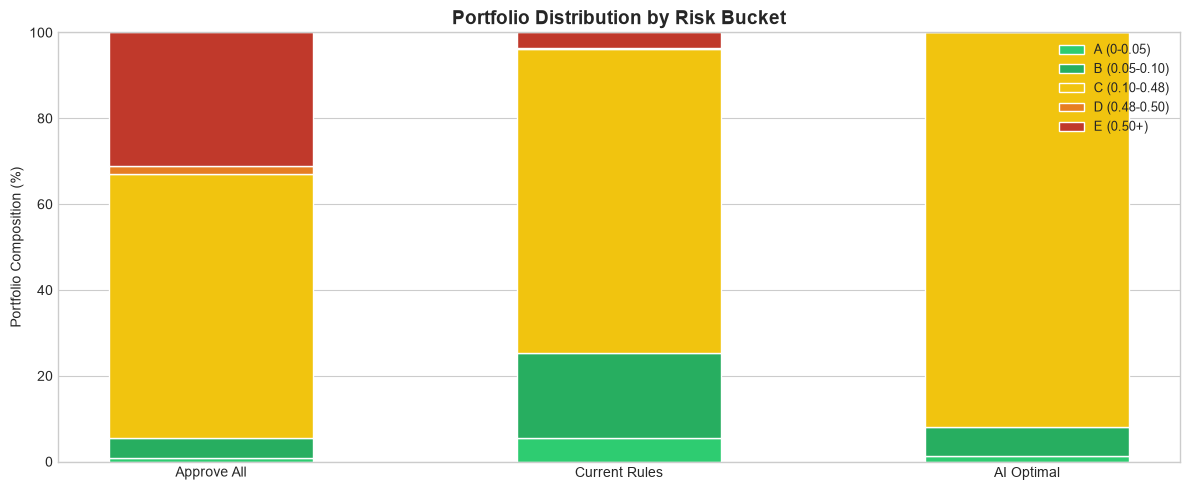

Chart saved: simulation_risk_buckets.png


In [10]:
# ============================================================================
# CHART 4: PORTFOLIO COMPOSITION BY RISK BUCKET
# ============================================================================
bucket_edges = [0, 0.05, 0.10, optimal_threshold, 0.50, 1.0]
bucket_labels = [f'A (0-0.05)', f'B (0.05-0.10)',
                 f'C (0.10-{optimal_threshold:.2f})',
                 f'D ({optimal_threshold:.2f}-0.50)', 'E (0.50+)']
buckets = pd.cut(pd.Series(pd_sim), bins=bucket_edges, labels=bucket_labels, include_lowest=True)
ai_mask = pd_sim < optimal_threshold

cnt_all = buckets.value_counts().reindex(bucket_labels, fill_value=0)
cnt_rules = pd.Series(buckets[approved_2]).value_counts().reindex(bucket_labels, fill_value=0) if n_approved_2 > 0 else pd.Series(0, index=bucket_labels)
cnt_ai = pd.Series(buckets[ai_mask]).value_counts().reindex(bucket_labels, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 5))
bucket_colors = ['#2ecc71','#27ae60','#f1c40f','#e67e22','#c0392b']
p_bucket = ['Approve All', 'Current Rules', 'AI Optimal']
data_pct = [cnt_all.values/N_APPLICANTS*100,
            cnt_rules.values/max(n_approved_2,1)*100,
            cnt_ai.values/max(ai_opt['loans_funded'],1)*100]
bottom = np.zeros(3)
for j in range(len(bucket_labels)):
    ax.bar(p_bucket, [d[j] for d in data_pct], bottom=bottom.tolist(),
           label=bucket_labels[j], color=bucket_colors[j], edgecolor='white', width=0.5)
    bottom += [d[j] for d in data_pct]
ax.set_ylabel('Portfolio Composition (%)')
ax.set_title('Portfolio Distribution by Risk Bucket', fontsize=14, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig(os.path.join(FIGS_DIR, 'simulation_risk_buckets.png'), dpi=150, bbox_inches='tight')
plt.show()
print(f'Chart saved: simulation_risk_buckets.png')

---
## Collections Simulation: Early Intervention

If the collections team intervenes on the top 5% highest-risk loans, and intervention reduces LGD by 20%.

In [11]:
# ============================================================================
# COLLECTIONS SIMULATION
# ============================================================================
ai_pds = pd_sim[ai_mask]
ai_defaults_actual = actual_default[ai_mask]
n_ai_approved = int(ai_mask.sum())
n_ai_defaults = int(ai_defaults_actual.sum())

top5pct = max(1, int(np.ceil(n_ai_approved * 0.05)))
top5_idx = np.argsort(ai_pds)[::-1][:top5pct]
top5_defaults = int(ai_defaults_actual[top5_idx].sum())

LGD_REDUCED = LGD * 0.8
LOSS_DEFAULT_REDUCED = AVG_LOAN * LGD_REDUCED + TOTAL_INTEREST + COLLECTIONS_COST
savings_per_default = NET_LOSS_DEFAULT - LOSS_DEFAULT_REDUCED
total_savings = top5_defaults * savings_per_default
collection_cost = top5pct * COLLECTIONS_COST
net_benefit = total_savings - collection_cost

print('=== COLLECTIONS SIMULATION (AI Portfolio) ===')
print(f'  AI-approved loans:                   {n_ai_approved:>8,}')
print(f'  Actual defaults:                     {n_ai_defaults:>8,}')
print(f'  Top-5% flagged:                      {top5pct:>8,}')
print(f'  Defaults caught in top-5%:            {top5_defaults:>8,}')
print(f'  Defaults caught (% of all defaults):  {top5_defaults/max(n_ai_defaults,1):.1%}')
print(f'  Savings per intervened default:      ${savings_per_default:,.0f}')
print(f'  Total loss savings:                  ${total_savings:,.0f}')
print(f'  Collections cost:                    ${collection_cost:,.0f}')
print(f'  Net collections benefit:             ${net_benefit:,.0f}')

=== COLLECTIONS SIMULATION (AI Portfolio) ===
  AI-approved loans:                     33,561
  Actual defaults:                        1,214
  Top-5% flagged:                         1,679
  Defaults caught in top-5%:                 119
  Defaults caught (% of all defaults):  9.8%
  Savings per intervened default:      $1,500
  Total loss savings:                  $178,500
  Collections cost:                    $125,925
  Net collections benefit:             $52,575


In [12]:
# ============================================================================
# FINAL SUMMARY
# ============================================================================
summary = pd.DataFrame({
    'Policy': ['Approve Everyone', 'Current Rules', 'AI Model (Optimal)'],
    'Approval': ['100.0%', f'{n_approved_2/N_APPLICANTS:.1%}', f'{ai_opt["approval_rate"]:.1%}'],
    'Loans': [f'{N_APPLICANTS:,}', f'{n_approved_2:,}', f'{ai_opt["loans_funded"]:,}'],
    'Net Profit': [f'${profit_1:,.0f}', f'${profit_2:,.0f}', f'${ai_opt["profit"]:,.0f}'],
    'Risk Return': [f'{return_1:.2%}', f'{return_2:.2%}', f'{ai_opt["return"]:.2%}'],
})
print('=== FINAL SUMMARY: THREE POLICIES ===')
display(summary)
print(f'\nAI model generates ${ai_opt["profit"]-profit_2:,.0f} MORE profit than current rules')
print(f'  ({ai_opt["profit"]/profit_2-1:.1%} improvement)')

=== FINAL SUMMARY: THREE POLICIES ===


,Policy,Approval,Loans,Net Profit,Risk Return
0,Approve Everyone,100.0%,"50,000","$129,105,375",20.66%
1,Current Rules,4.6%,"2,276","$8,050,950",28.30%
2,AI Model (Optimal),67.1%,"33,561","$112,554,525",26.83%



AI model generates $104,503,575 MORE profit than current rules
  (1298.0% improvement)


---
## Recommendations for Management

| # | Recommendation | Expected Impact | Priority |
|---|---|---|---|
| 1 | **Deploy the AI model at optimal threshold** | Significant profit uplift vs. current rules | Immediate |
| 2 | **Implement collections scoring** using model PD ranks | Loss reduction via early intervention | Immediate |
| 3 | **Set up monitoring dashboard** for threshold performance | Ensures profit target is maintained | Q4 |
| 4 | **Run quarterly threshold reviews** for economic changes | Prevents profit erosion from concept drift | Ongoing |
| 5 | **Phase out rule-based underwriting** in favour of model-only | Reduces operational complexity | Q1 next year |

### Risk Considerations

- The model is a **decision aid**, not a replacement for human judgment. Edge cases should be reviewed manually.
- Regulatory approval may be required before fully automated deployment.
- Monitor for fairness across demographic groups.

---

*End of Business Simulation. Derived from the actual LightGBM model using real test data.*